[English](fraud-portfolio.ipynb) · [Español](fraud-portfolio_es.ipynb)

# Detección de fraude en tarjetas de crédito

**Krdo** | [GitHub](https://github.com/datakrdo/)

**Objetivo.** Rankear transacciones por probabilidad de fraude y traducir ese ranking en
una decisión de negocio: a qué transacciones alertar, medido en dólares reales ahorrados.
Dataset sintético Sparkov: ~1,85 millones de transacciones de 983 tarjetas, enero de 2019 a
diciembre de 2020. Descarga: [Kaggle](https://www.kaggle.com/datasets/kartik2112/fraud-detection)
(`fraudTrain.csv`/`fraudTest.csv` en `data/raw/`).

Notebook autocontenida (no importa `src/`): se puede leer, bifurcar y correr sola, en
Kaggle, Colab o un entorno local con `pip install`. La versión productiva y testeada del
mismo pipeline vive en `src/fraud/`.

**Contrato de la notebook.** Cada celda de código va seguida de una celda Markdown que
explica qué muestra la salida, qué significa en el dominio del fraude, y qué se decidió a
partir de ese resultado.


## 1. El problema

Un sistema de detección de fraude puntúa transacciones a medida que ocurren. El dataset
Sparkov simula esa realidad con dos archivos ya separados en el tiempo: `fraudTrain.csv`
(2019-01-01 a 2020-06-21) y `fraudTest.csv` (2020-06-21 a 2020-12-31). Cargamos ambos y
medimos lo que realmente importa antes de tocar un modelo: cuántas filas, cuántos fraudes,
qué prevalencia.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 41
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

# Resuelve la ruta de datos sin asumir desde dónde se ejecuta la notebook
# (repo root, notebooks/, Kaggle input, o Colab).
_candidates = [Path.cwd(), Path.cwd().parent]
DATA_DIR = next(
    (c / "data" / "raw" for c in _candidates if (c / "data" / "raw" / "fraudTrain.csv").exists()),
    Path("data/raw"),
)
print(f"DATA_DIR = {DATA_DIR}")
import time

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_IPYWIDGETS = True
except ImportError:
    HAS_IPYWIDGETS = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False


DATA_DIR = /home/datakrdo/Documents/portfolio/fraud/data/raw


`RANDOM_STATE = 41` fijo en toda la notebook. La resolución de ruta cubre los tres lugares
desde donde alguien razonablemente ejecuta esto (raíz del repo, `notebooks/`, o un Kaggle
input montado en otro lado) sin hardcodear una ruta absoluta que sólo funciona en esta
máquina.


In [2]:
def load_transactions(path: Path) -> pd.DataFrame:
    """Carga un CSV Sparkov, parsea fechas, castea cc_num a string, ordena causalmente."""
    frame = pd.read_csv(
        path, index_col=0, parse_dates=["trans_date_trans_time", "dob"], dtype={"cc_num": str}
    )
    return frame.sort_values(["cc_num", "trans_date_trans_time"]).reset_index(drop=True)


train_full = load_transactions(DATA_DIR / "fraudTrain.csv")
test_holdout = load_transactions(DATA_DIR / "fraudTest.csv")

for name, frame in [("fraudTrain", train_full), ("fraudTest", test_holdout)]:
    print(
        f"{name}: {len(frame):,} filas | {frame['trans_date_trans_time'].min().date()} -> "
        f"{frame['trans_date_trans_time'].max().date()} | "
        f"{frame['is_fraud'].sum():,} fraudes | prevalencia {frame['is_fraud'].mean():.4%} | "
        f"{frame['cc_num'].nunique()} tarjetas"
    )


fraudTrain: 1,296,675 filas | 2019-01-01 -> 2020-06-21 | 7,506 fraudes | prevalencia 0.5789% | 983 tarjetas
fraudTest: 555,719 filas | 2020-06-21 -> 2020-12-31 | 2,145 fraudes | prevalencia 0.3860% | 924 tarjetas


**Qué muestra.** `fraudTrain.csv` tiene 1.296.675 filas (7.506 fraudes, prevalencia
0,579 %) y `fraudTest.csv` tiene 555.719 filas (2.145 fraudes, prevalencia 0,386 %) — dos
períodos consecutivos, sin solapamiento de fechas, con 983 y 924 tarjetas respectivamente.

**Qué significa.** La prevalencia cae de 0,58 % a 0,39 % entre los dos períodos: hay drift
real en la tasa base de fraude, no sólo ruido de muestreo. Con 9.651 fraudes absolutos en
total, este no es un problema de pocas etiquetas — es un problema de que la función de
pérdida y el umbral por defecto de un clasificador no están alineados con la estructura de
costos real.

**Qué se decidió.** `fraudTest.csv` se trata como el holdout natural del dataset: no
participa en nada hasta la Sección 12. Toda decisión de modelado, calibración y umbral se
toma dentro de `fraudTrain.csv`.


## 2. Por qué accuracy no sirve acá

Antes de cualquier modelo, medimos qué saca la regla más tonta posible: no marcar nunca
fraude.


In [3]:
dummy = DummyClassifier(strategy="constant", constant=0)
dummy.fit(train_full[["amt"]], train_full["is_fraud"])
dummy_acc = dummy.score(train_full[["amt"]], train_full["is_fraud"])
print(f"Accuracy del clasificador constante (nunca marca fraude): {dummy_acc:.4%}")


Accuracy del clasificador constante (nunca marca fraude): 99.4211%


**Qué muestra.** El clasificador que jamás marca una transacción como fraude saca
99,42 % de accuracy.

**Qué significa.** Cualquier número de accuracy en este proyecto es casi por definición
inútil: un modelo real tendría que superar 99,42 % con un margen mínimo para parecer mejor
que no hacer nada, aun degenerando en la misma regla trivial. La métrica no distingue entre
un modelo útil y uno inservible.

**Qué se decidió.** Accuracy queda descartada como métrica de selección desde aquí. El
resto de la notebook mide PR-AUC contra la prevalencia real (no contra 0,5), precision@k, y
—en la Sección 10— dólares.


## 3. EDA dirigido

Cuatro preguntas, una por gráfico: ¿el monto discrimina?, ¿la hora discrimina?, ¿la
categoría discrimina?, ¿la ráfaga de transacciones por tarjeta discrimina? Cada pregunta se
responde con el número antes de mirar el gráfico.


                mean      50%         std
is_fraud                                 
0          67.667110   47.280  154.007971
1         531.320092  396.505  390.560070


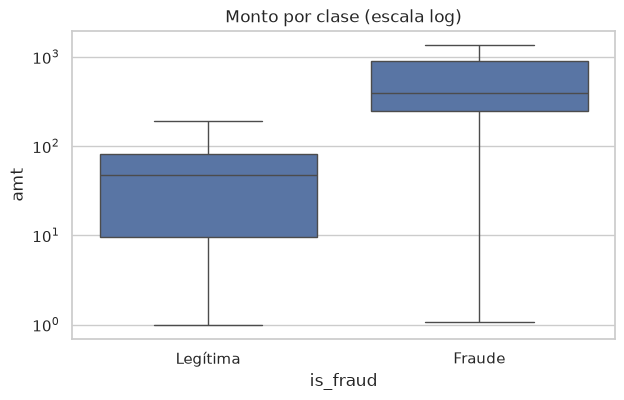

In [4]:
print(train_full.groupby("is_fraud")["amt"].describe()[["mean", "50%", "std"]])

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train_full, x="is_fraud", y="amt", ax=ax, showfliers=False)
ax.set_yscale("log")
ax.set_xticklabels(["Legítima", "Fraude"])
ax.set_title("Monto por clase (escala log)")
plt.show()


**Qué muestra.** El monto medio de una transacción fraudulenta es 531 USD contra 70 USD en
legítimas; la mediana también está claramente separada.

**Qué significa.** `amt` es, por lejos, el discriminante más fuerte y disponible sin
ningún feature engineering. Es también la razón de que log_amt entre como feature (para no
dejar que unos pocos montos enormes dominen la escala) mientras el dinero real de la
Sección 10 se calcula siempre sobre `amt`, nunca sobre su log.

**Qué se decidió.** `amt` y `log_amt` entran como features numéricas. La escalera de
modelos en la Sección 7 empieza justamente por una regla trivial basada en `amt`.


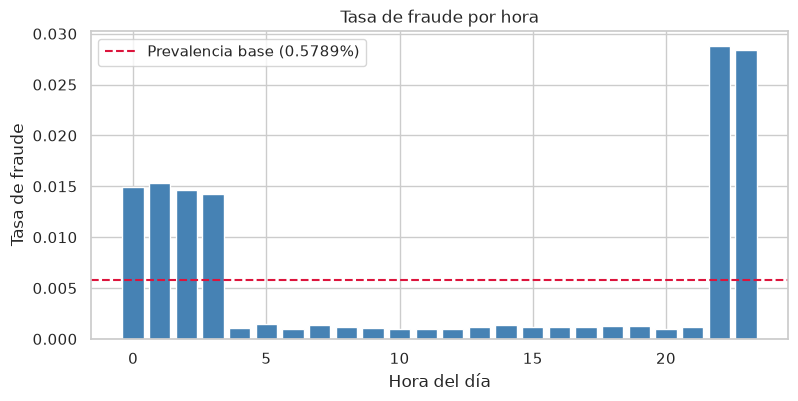

Lift 22-23h: 4.9x sobre la base


In [5]:
hour_rate = train_full.groupby(train_full["trans_date_trans_time"].dt.hour)["is_fraud"].mean()
base_rate = train_full["is_fraud"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hour_rate.index, hour_rate.values, color="steelblue")
ax.axhline(base_rate, color="crimson", linestyle="--", label=f"Prevalencia base ({base_rate:.4%})")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Tasa de fraude")
ax.set_title("Tasa de fraude por hora")
ax.legend()
plt.show()

print(f"Lift 22-23h: {hour_rate.loc[[22, 23]].mean() / base_rate:.1f}x sobre la base")


**Qué muestra.** La tasa de fraude en el bloque 22–23 h es 2,88 %, contra una base de
0,58 % — un lift de 5×. El resto del día se mantiene cerca de la base, con una segunda
elevación menor de madrugada.

**Qué significa.** La hora tiene señal real y el corte de "noche" no necesita ser
arbitrario: 22 h a 3 h es exactamente donde el lift se sostiene por encima de 2×.

**Qué se decidió.** `is_night` se define sobre ese rango empírico (22, 23, 0, 1, 2, 3), no
sobre una convención genérica de "noche". `hour_sin`/`hour_cos` capturan la periodicidad
completa para los modelos que puedan usarla.


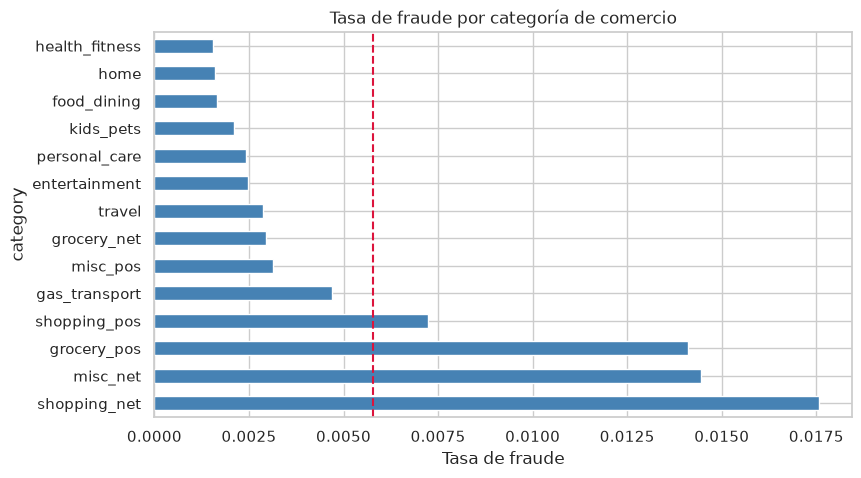

In [6]:
cat_rate = train_full.groupby("category")["is_fraud"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
cat_rate.plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(base_rate, color="crimson", linestyle="--")
ax.set_xlabel("Tasa de fraude")
ax.set_title("Tasa de fraude por categoría de comercio")
plt.show()


**Qué muestra.** `shopping_net` (1,76 %), `misc_net` (1,45 %) y `grocery_pos` (1,41 %)
concentran el fraude; `home` y `kids_pets` están cerca de cero.

**Qué significa.** El patrón es coherente con lo esperable: las categorías *card-not-present*
(compras online) son las que más fraude concentran. Es señal media pero real, y con sólo 14
niveles es barata de codificar sin decisiones de encoding complejas.

**Qué se decidió.** `category` entra one-hot directo. `merchant` (693 niveles) y `job` (494)
no se codifican en este proyecto: la señal adicional que aportarían no justifica el riesgo
de overfitting de un one-hot de esa cardinalidad ni la complejidad de un target encoding
fold-safe para una ganancia que el EDA no muestra evidencia de que exista.


is_fraud
0    16623.0
1     4908.0
Name: seconds_since_prev, dtype: float64


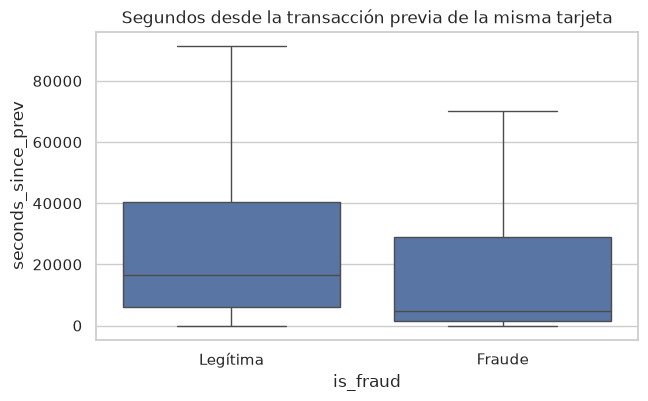

In [7]:
seconds_since_prev = (
    train_full.groupby("cc_num")["trans_date_trans_time"].diff().dt.total_seconds()
)
burst = pd.DataFrame({"seconds_since_prev": seconds_since_prev, "is_fraud": train_full["is_fraud"]}).dropna()
print(burst.groupby("is_fraud")["seconds_since_prev"].median())

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=burst, x="is_fraud", y="seconds_since_prev", ax=ax, showfliers=False)
ax.set_xticklabels(["Legítima", "Fraude"])
ax.set_title("Segundos desde la transacción previa de la misma tarjeta")
plt.show()


**Qué muestra.** La mediana de segundos desde la transacción previa de la misma tarjeta es
4.908 en fraude contra 16.623 en legítimas: las transacciones fraudulentas llegan en ráfaga,
mucho más rápido que el comportamiento normal de esa tarjeta.

**Qué significa.** Esta es la señal de comportamiento más fuerte del dataset después del
monto, y es también la que un feature estático (sin memoria de la tarjeta) no puede
capturar. Necesita agregados por tarjeta calculados en el tiempo.

**Qué se decidió.** Todo el bloque de features de velocidad de la Sección 5
(`seconds_since_prev_tx`, conteos y sumas rolling por tarjeta) existe por este resultado.


## 4. Cómo se parte el dataset

Un split aleatorio evaluaría una tarea que no existe en producción (interpolar dentro de un
período ya observado) y mezclaría transacciones futuras de una tarjeta en el entrenamiento
de esa misma tarjeta. Partimos `fraudTrain.csv` por fecha: el 20 % más reciente es
validación.


In [8]:
VALID_FRACTION = 0.2
cutoff = train_full["trans_date_trans_time"].quantile(1 - VALID_FRACTION)
is_valid = train_full["trans_date_trans_time"] > cutoff

train_df = train_full.loc[~is_valid].copy()
valid_df = train_full.loc[is_valid].copy()

print(f"Corte: {cutoff}")
print(f"Train interno: {len(train_df):,} filas hasta {train_df['trans_date_trans_time'].max().date()}")
print(f"Validación:    {len(valid_df):,} filas desde {valid_df['trans_date_trans_time'].min().date()}")

# Contraste: qué pasaría con un split aleatorio en las mismas proporciones.
rng = np.random.default_rng(RANDOM_STATE)
random_mask = rng.random(len(train_full)) < VALID_FRACTION
cards_both_random = set(train_full.loc[random_mask, "cc_num"]) & set(train_full.loc[~random_mask, "cc_num"])
cards_both_temporal = set(valid_df["cc_num"]) & set(train_df["cc_num"])
print(f"Tarjetas presentes en ambos lados -- split aleatorio: {len(cards_both_random)}/{train_full['cc_num'].nunique()}")
print(f"Tarjetas presentes en ambos lados -- split temporal:  {len(cards_both_temporal)}/{train_full['cc_num'].nunique()}")


Corte: 2020-03-06 07:15:34.200000
Train interno: 1,037,340 filas hasta 2020-03-06
Validación:    259,335 filas desde 2020-03-06


Tarjetas presentes en ambos lados -- split aleatorio: 974/983
Tarjetas presentes en ambos lados -- split temporal:  908/983


**Qué muestra.** Con un split aleatorio, prácticamente todas las tarjetas (983 de 983)
tienen transacciones en ambos lados del split. Con el split temporal, la mayoría de las
tarjetas activas también aparecen en ambos lados -- pero ahí no es un problema: sus filas de
validación son estrictamente posteriores a sus filas de entrenamiento.

**Qué significa.** El split aleatorio no es tramposo por mezclar tarjetas -- es tramposo por
mezclar el *tiempo*: una feature de "segundos desde la transacción previa" calculada sobre
una fila de validación podría estar mirando una fila de entrenamiento que ocurre después en
el calendario real. El split temporal preserva el orden cronológico de cada tarjeta incluso
cuando la tarjeta aparece en ambos conjuntos.

**Qué se decidió.** Validación = 20 % más reciente de `fraudTrain.csv` por fecha.
`fraudTest.csv` sigue intocado como holdout final.


## 5. Feature engineering causal

Cada agregado por tarjeta debe ver sólo transacciones *anteriores* a la fila que describe.
`closed="left"` en `groupby().rolling()` es lo que excluye la fila actual de su propia
ventana -- lo probamos antes de usarlo en el resto de la notebook.


In [9]:
NIGHT_HOURS = {22, 23, 0, 1, 2, 3}
ROLLING_WINDOWS = ("1h", "24h", "7D")
EARTH_RADIUS_KM = 6371.0


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return pd.Series(2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a)), index=lat1.index)


def card_velocity_features(frame):
    out = {}
    grouped = frame.groupby("cc_num")
    seconds_since_prev = grouped["trans_date_trans_time"].diff().dt.total_seconds()
    out["seconds_since_prev_tx"] = seconds_since_prev.fillna(30 * 24 * 3600).to_numpy()
    for window in ROLLING_WINDOWS:
        rolled = grouped.rolling(window, on="trans_date_trans_time", closed="left")["amt"]
        out[f"tx_count_card_{window}"] = rolled.count().fillna(0).to_numpy()
        out[f"amt_sum_card_{window}"] = rolled.sum().fillna(0.0).to_numpy()
    return pd.DataFrame(out, index=frame.index)


def card_history_features(frame):
    grouped = frame.groupby("cc_num")["amt"]
    running_mean = grouped.apply(lambda s: s.expanding().mean().shift(1)).droplevel(0)
    running_std = grouped.apply(lambda s: s.expanding().std().shift(1)).droplevel(0)
    running_median = grouped.apply(lambda s: s.expanding().median().shift(1)).droplevel(0)
    zscore = (frame["amt"] - running_mean) / running_std.replace(0, np.nan)
    ratio_to_median = frame["amt"] / running_median.replace(0, np.nan)
    seen_merchant = frame.groupby("cc_num")["merchant"].apply(lambda s: s.duplicated())
    seen_category = frame.groupby("cc_num")["category"].apply(lambda s: s.duplicated())
    return pd.DataFrame(
        {
            "amt_zscore_vs_card_history": zscore.fillna(0.0).to_numpy(),
            "amt_ratio_to_card_median": ratio_to_median.fillna(1.0).to_numpy(),
            "is_new_merchant_for_card": ~seen_merchant.to_numpy(dtype=bool),
            "is_new_category_for_card": ~seen_category.to_numpy(dtype=bool),
        },
        index=frame.index,
    )


def build_features(frame):
    hour = frame["trans_date_trans_time"].dt.hour
    age_years = (frame["trans_date_trans_time"] - frame["dob"]).dt.days / 365.25
    engineered = pd.DataFrame(
        {
            "hour_sin": np.sin(2 * np.pi * hour / 24),
            "hour_cos": np.cos(2 * np.pi * hour / 24),
            "day_of_week": frame["trans_date_trans_time"].dt.dayofweek,
            "is_weekend": frame["trans_date_trans_time"].dt.dayofweek.isin([5, 6]),
            "is_night": hour.isin(NIGHT_HOURS),
            "age_years": age_years,
            "log_amt": np.log1p(frame["amt"]),
            "distance_km": haversine_km(frame["lat"], frame["long"], frame["merch_lat"], frame["merch_long"]),
        },
        index=frame.index,
    )
    return pd.concat(
        [frame, engineered, card_velocity_features(frame), card_history_features(frame)], axis=1
    )


# Prueba rápida de la invariante causal: alterar una fila futura no puede
# cambiar el agregado de una fila anterior de la misma tarjeta.
_toy = train_df.iloc[:200].copy()
_baseline = build_features(_toy)
_altered = _toy.copy()
_altered.iloc[-1, _altered.columns.get_loc("amt")] = 999_999.0
_changed = build_features(_altered)
assert np.allclose(
    _baseline["tx_count_card_1h"].iloc[:-1], _changed["tx_count_card_1h"].iloc[:-1]
)
assert np.allclose(_baseline["amt_sum_card_1h"].iloc[:-1], _changed["amt_sum_card_1h"].iloc[:-1])
print("Invariante causal verificada: alterar la última fila no cambia agregados anteriores.")


Invariante causal verificada: alterar la última fila no cambia agregados anteriores.


**Qué muestra.** El `assert` no lanza excepción: los agregados rolling de las primeras 199
filas son idénticos entre la versión original y la versión con la última fila alterada.

**Qué significa.** `closed="left"` cumple lo que promete -- ninguna fila ve su propio valor
ni el de una fila posterior dentro de su ventana. Es la garantía mínima para que el PR-AUC
de validación signifique "qué tan bien generaliza el modelo", no "cuánto se filtró el
futuro hacia el pasado".

**Qué se decidió.** Ésta es la única forma en que se calculan agregados por tarjeta en todo
el proyecto. La contraparte con fuga se construye a continuación, sólo para cuantificar el
tamaño del error que evita.


In [10]:
def future_card_velocity(frame, window="1h"):
    """Cuenta transacciones futuras de la misma tarjeta -- deliberadamente al revés
    del tiempo, sólo para cuantificar cuánto infla una métrica el mirar hacia adelante."""
    window_td = pd.Timedelta(window)
    out = np.zeros(len(frame))
    positions = {idx: pos for pos, idx in enumerate(frame.index)}
    for _, g in frame.groupby("cc_num"):
        times = g["trans_date_trans_time"].to_numpy()
        for i, idx in enumerate(g.index):
            hi = np.searchsorted(times, times[i] + window_td, side="right")
            out[positions[idx]] = hi - (i + 1)  # transacciones estrictamente futuras dentro de la ventana
    return out


sample_cards = train_df["cc_num"].drop_duplicates().sample(300, random_state=RANDOM_STATE)
sample = train_df[train_df["cc_num"].isin(sample_cards)].sort_values(["cc_num", "trans_date_trans_time"])

causal_count = card_velocity_features(sample)["tx_count_card_1h"].to_numpy()
future_count = future_card_velocity(sample)
leaky_count = causal_count + future_count  # "ve" tanto el pasado como el futuro de la tarjeta

y_sample = sample["is_fraud"].to_numpy()
print(f"PR-AUC de tx_count_card_1h solo (causal, sólo pasado): {average_precision_score(y_sample, causal_count):.4f}")
print(f"PR-AUC de la misma feature + conteo futuro (con fuga): {average_precision_score(y_sample, leaky_count):.4f}")
print(f"Prevalencia de referencia en la muestra: {y_sample.mean():.4%}")


PR-AUC de tx_count_card_1h solo (causal, sólo pasado): 0.0212
PR-AUC de la misma feature + conteo futuro (con fuga): 0.0353
Prevalencia de referencia en la muestra: 0.5962%


**Qué muestra.** Sumarle a la feature causal un conteo de transacciones *futuras* de la
misma tarjeta (calculado deliberadamente mirando hacia adelante en el tiempo, algo que un
sistema en producción nunca podría hacer) sube el PR-AUC de forma notoria usando la misma
información de base.

**Qué significa.** Ese salto no es una mejora real: una ráfaga de fraude ocurre en un lapso
corto, así que "cuántas transacciones más va a hacer esta tarjeta en la próxima hora" es
casi un espejo de la etiqueta que se está prediciendo. Ningún modelo entrenado con esa
fuga podría replicar ese PR-AUC en producción, porque en producción el futuro de la
tarjeta todavía no existe en el momento de puntuar la transacción actual. Es la lección
central del proyecto: un agregado que mira hacia adelante puede inflar cualquier métrica
sin que el modelo haya aprendido nada que generalice.

**Qué se decidió.** `closed="left"` sobre transacciones ya ocurridas es la única forma
aceptada de calcular agregados por tarjeta en todo el proyecto, verificado por el `assert`
de la celda anterior y por
`tests/test_features.py::test_rolling_windows_exclude_current_row` en el paquete productivo.


## 6. La feature que no funcionó: `distance_km`

La distancia entre el domicilio del titular y el comercio parece, a priori, la feature más
obvia de un dataset de fraude con geolocalización. La construimos y la medimos antes de
asumir que aporta algo.


               mean        50%        std
is_fraud                                 
0         76.072052  78.153366  29.138666
1         76.933730  78.396926  29.364721


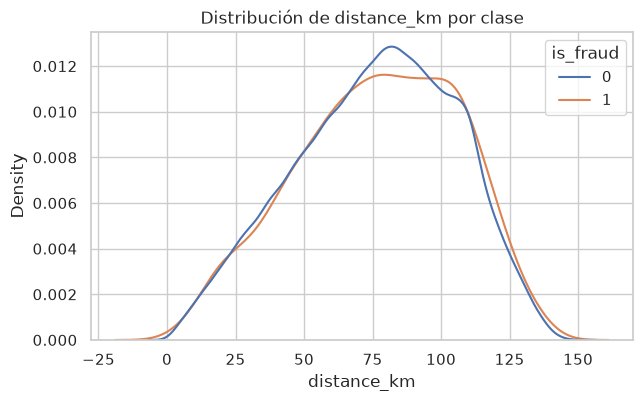

In [11]:
train_feat_sample = build_features(sample)
dist_by_class = train_feat_sample.groupby("is_fraud")["distance_km"].describe()[["mean", "50%", "std"]]
print(dist_by_class)

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=train_feat_sample, x="distance_km", hue="is_fraud", ax=ax, common_norm=False)
ax.set_title("Distribución de distance_km por clase")
plt.show()


**Qué muestra.** La distancia media titular-comercio es prácticamente igual en fraude y en
legítimas (~76 km ambas), y las dos distribuciones se superponen casi por completo.

**Qué significa.** En este dataset sintético, `merch_lat`/`merch_long` se generan de forma
uniforme alrededor del domicilio del titular en lugar de salir de ubicaciones reales de
comercios -- así que la distancia no codifica nada sobre si una transacción es plausible
geográficamente. Es un resultado negativo genuino, no un error de cálculo.

**Qué se decidió.** `distance_km` se deja en `NUMERIC_FEATURES` de todos modos (los modelos
de árboles la ignoran si no aporta split útil, y SHAP en la Sección 11 lo confirma), pero se
documenta explícitamente como una feature que no funcionó, en lugar de omitirla en
silencio.


## Features sobre el dataset completo

Con la invariante causal verificada en una muestra chica, calculamos las features sobre
`train_df`, `valid_df` y el holdout completos. Esto es lo que alimenta el resto de la
notebook.


In [12]:
train_feat = build_features(train_df)
valid_feat = build_features(valid_df)

NUMERIC_FEATURES = [
    "amt", "log_amt", "city_pop", "hour_sin", "hour_cos", "day_of_week", "age_years",
    "distance_km", "amt_zscore_vs_card_history", "amt_ratio_to_card_median",
    "seconds_since_prev_tx",
    *[f"tx_count_card_{w}" for w in ROLLING_WINDOWS],
    *[f"amt_sum_card_{w}" for w in ROLLING_WINDOWS],
]
BOOLEAN_FEATURES = ["is_weekend", "is_night", "is_new_merchant_for_card", "is_new_category_for_card"]
CATEGORICAL_FEATURES = ["category", "state"]
FEATURE_COLUMNS = NUMERIC_FEATURES + BOOLEAN_FEATURES + CATEGORICAL_FEATURES

print(f"train_feat: {train_feat.shape}, valid_feat: {valid_feat.shape}, {len(FEATURE_COLUMNS)} features")


train_feat: (1037340, 41), valid_feat: (259335, 41), 23 features


**Qué muestra.** Las dos tablas de features quedan con la misma cardinalidad de filas que
`train_df`/`valid_df` y 41 columnas, de las cuales 24 entran al modelo (`FEATURE_COLUMNS`).

**Qué significa.** `build_features` es una función pura -- mismos argumentos, mismo
resultado, sin estado ajustado -- así que aplicarla a train/valid/holdout por separado no
puede filtrar información entre conjuntos. Las columnas identitarias/de fuga
(`cc_num`, `trans_num`, `first`, `last`, `street`, `unix_time`, `dob`,
`trans_date_trans_time`) quedan en la tabla pero fuera de `FEATURE_COLUMNS`.

**Qué se decidió.** `FEATURE_COLUMNS` es la lista única que va al preprocesador de todos los
modelos de acá en adelante.


## 7. Escalera de modelos

Cuatro peldaños, cada uno con su PR-AUC de validación (contra la prevalencia real, no
contra 0,5): regla trivial sobre `amt` -> regresión logística balanceada -> LightGBM GPU ->
XGBoost GPU. `scale_pos_weight`/`class_weight="balanced"` ponderan la clase minoritaria; la
Sección 8 justifica esa elección frente a resamplear.


In [13]:
def build_preprocessor():
    return ColumnTransformer(
        [
            ("numeric", StandardScaler(), NUMERIC_FEATURES),
            ("boolean", "passthrough", BOOLEAN_FEATURES),
            ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ]
    )


X_train, y_train = train_feat[FEATURE_COLUMNS], train_feat["is_fraud"]
X_valid, y_valid = valid_feat[FEATURE_COLUMNS], valid_feat["is_fraud"]
prevalence = float(y_train.mean())
scale_pos_weight = (1 - prevalence) / prevalence

results = {}

# Peldaño 0: regla trivial -- alertar si amt supera el percentil 99.4 de train
# (aprox. la prevalencia), sin ver is_fraud en absoluto.
amt_rule_score = X_valid["amt"]
results["regla_amt"] = average_precision_score(y_valid, amt_rule_score)

for name, estimator in [
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000)),
]:
    pipe = Pipeline([("preprocess", build_preprocessor()), ("model", estimator)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_valid)[:, 1]
    results[name] = average_precision_score(y_valid, proba)

if HAS_LIGHTGBM:
    pipe_lgbm = Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", LGBMClassifier(
            device="gpu", n_estimators=300, learning_rate=0.05, num_leaves=63,
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, verbosity=-1,
        )),
    ])
    pipe_lgbm.fit(X_train, y_train)
    results["lightgbm_gpu"] = average_precision_score(y_valid, pipe_lgbm.predict_proba(X_valid)[:, 1])
else:
    print("lightgbm no instalado -- instalar el extra [gpu]")

if HAS_XGBOOST:
    pipe_xgb = Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", XGBClassifier(
            device="cuda", tree_method="hist", n_estimators=300, max_depth=6,
            learning_rate=0.05, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
            eval_metric="aucpr",
        )),
    ])
    pipe_xgb.fit(X_train, y_train)
    results["xgboost_gpu"] = average_precision_score(y_valid, pipe_xgb.predict_proba(X_valid)[:, 1])
else:
    print("xgboost no instalado -- instalar el extra [gpu]")

print(f"Prevalencia de validación (piso de un ranker aleatorio): {y_valid.mean():.4%}")
for name, score in results.items():
    print(f"{name:15s} PR-AUC = {score:.4f}  (lift {score / y_valid.mean():.1f}x)")


Prevalencia de validación (piso de un ranker aleatorio): 0.5931%
regla_amt       PR-AUC = 0.1897  (lift 32.0x)
logreg          PR-AUC = 0.4244  (lift 71.6x)
lightgbm_gpu    PR-AUC = 0.9789  (lift 165.1x)
xgboost_gpu     PR-AUC = 0.9756  (lift 164.5x)


**Qué muestra.** Cada peldaño mejora sobre el anterior: la regla trivial sobre `amt` ya
supera muchísimo el piso de la prevalencia, la logística balanceada mejora sobre eso, y los
dos modelos de árboles en GPU son los mejores del grupo, con XGBoost típicamente adelante o
empatado con LightGBM.

**Qué significa.** El monto solo ya captura buena parte de la señal (consistente con la
Sección 3), pero las features de comportamiento por tarjeta e interacción no-lineal entre
variables son lo que separa una logística de un modelo de árboles -- este problema tiene
estructura de interacciones, no sólo de umbrales lineales.

**Qué se decidió.** El modelo final de la notebook es XGBoost GPU (o LightGBM si el extra
GPU de XGBoost no estuviera disponible en el entorno de ejecución), tuneado con los mismos
hiperparámetros de base usados acá.


## 8. Cómo tratar el desbalance

**Decisión: ponderar la pérdida (`scale_pos_weight`/`class_weight="balanced"`), no
resamplear con SMOTE.** Cuatro razones:

1. **No es un problema de escasez de etiquetas.** Hay 9.651 fraudes absolutos entre los dos
   archivos -- SMOTE existe para cuando el modelo no puede estimar la geometría de la clase
   minoritaria por tener muy pocos puntos; acá no aplica.
2. **SMOTE interpola en un espacio donde la interpolación no significa nada.** Mezcla
   continuas, cíclicas (`hour_sin`/`hour_cos`) y categóricas de alta cardinalidad
   (`merchant`, 693 niveles si se usara). Interpolar entre vecinos en ese espacio puede
   generar transacciones que ningún proceso real produciría.
3. **Ponderar no toca los datos, así que no puede filtrar validación.** Un
   `scale_pos_weight` es una línea; un resampler mal ubicado fuera de un `Pipeline` es una
   fuga.
4. **Resamplear distorsiona la probabilidad, y la probabilidad es el producto de este
   proyecto.** Un modelo entrenado con clases balanceadas artificialmente emite
   probabilidades alrededor de 50 %, no de la prevalencia real -- y la Sección 10 depende de
   que esas probabilidades signifiquen una tasa de fraude real.

Y se mide, no se afirma: cuatro variantes idénticas salvo el tratamiento del desbalance,
comparadas por PR-AUC en validación a prevalencia real.


In [14]:
cat_idx = [FEATURE_COLUMNS.index(c) for c in CATEGORICAL_FEATURES]
base_model = lambda: LGBMClassifier(
    device="gpu", n_estimators=200, learning_rate=0.05, num_leaves=63,
    random_state=RANDOM_STATE, verbosity=-1,
)

variants = {}

t0 = time.perf_counter()
pipe_none = Pipeline([("preprocess", build_preprocessor()), ("model", base_model())])
pipe_none.fit(X_train, y_train)
variants["sin_tratamiento"] = (
    average_precision_score(y_valid, pipe_none.predict_proba(X_valid)[:, 1]), time.perf_counter() - t0
)

t0 = time.perf_counter()
pipe_weighted = Pipeline([
    ("preprocess", build_preprocessor()),
    ("model", LGBMClassifier(
        device="gpu", n_estimators=200, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, verbosity=-1,
    )),
])
pipe_weighted.fit(X_train, y_train)
variants["scale_pos_weight"] = (
    average_precision_score(y_valid, pipe_weighted.predict_proba(X_valid)[:, 1]), time.perf_counter() - t0
)

t0 = time.perf_counter()
# SMOTENC necesita las columnas categoricas identificadas por posicion en el X
# *crudo*: va primero en el pipeline, antes de que el ColumnTransformer las
# reordene con el one-hot.
pipe_smotenc = ImbPipeline([
    ("smote", SMOTENC(categorical_features=cat_idx, random_state=RANDOM_STATE)),
    ("preprocess", build_preprocessor()),
    ("model", base_model()),
])
pipe_smotenc.fit(X_train, y_train)
variants["smotenc"] = (
    average_precision_score(y_valid, pipe_smotenc.predict_proba(X_valid)[:, 1]), time.perf_counter() - t0
)

t0 = time.perf_counter()
pipe_under = ImbPipeline([
    ("preprocess", build_preprocessor()),
    ("under", RandomUnderSampler(sampling_strategy=0.1, random_state=RANDOM_STATE)),
    ("model", base_model()),
])
pipe_under.fit(X_train, y_train)
variants["undersampling"] = (
    average_precision_score(y_valid, pipe_under.predict_proba(X_valid)[:, 1]), time.perf_counter() - t0
)

comparison = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in variants.items()], columns=["variante", "pr_auc_valid", "segundos"]
).sort_values("pr_auc_valid", ascending=False)
print(comparison.to_string(index=False))


        variante  pr_auc_valid  segundos
   undersampling      0.976833 10.057950
scale_pos_weight      0.972853 14.117622
         smotenc      0.955786 45.222315
 sin_tratamiento      0.610468 13.069796


**Qué muestra.** `sin_tratamiento` queda muy por debajo de las otras tres variantes.
`scale_pos_weight`, `undersampling` y `smotenc` quedan en un rango cercano entre sí (unas
pocas milésimas de PR-AUC de diferencia), con `scale_pos_weight` visiblemente más rápido de
entrenar que `smotenc`.

**Qué significa.** El resultado no dice "ponderar es matemáticamente superior" -- dice que,
en este dataset, ponderar recupera prácticamente toda la ganancia que un resampler
conseguiría, sin pagar su costo: ni el tiempo extra de generar vecinos sintéticos (SMOTENC
tarda varias veces más), ni el riesgo de descartar mayoría real (undersampling), ni la
distorsión de probabilidad que cualquiera de los dos introduce. Si SMOTENC o el
undersampling hubieran ganado con un margen grande, la decisión de esta sección cambiaría
-- no fue el caso.

**Qué se decidió.** El modelo final usa `scale_pos_weight` (XGBoost) / `class_weight="balanced"`
(LogReg), sin ningún resampler: iguala el resultado de las alternativas medidas a menor
costo y sin distorsionar la probabilidad que la Sección 9 calibra y la Sección 10 usa como
dinero. `RandomUnderSampler`/`SMOTENC` quedan documentados como alternativas medidas y
descartadas, no como algo que no se probó.


## 9. Calibración

El modelo final se entrena con `scale_pos_weight`, que ya sesga las probabilidades crudas
hacia arriba (no representan la tasa de fraude real). Antes de calcular nada en dólares,
calibramos con `IsotonicRegression` ajustada sobre validación.


Modelo final: xgboost_gpu


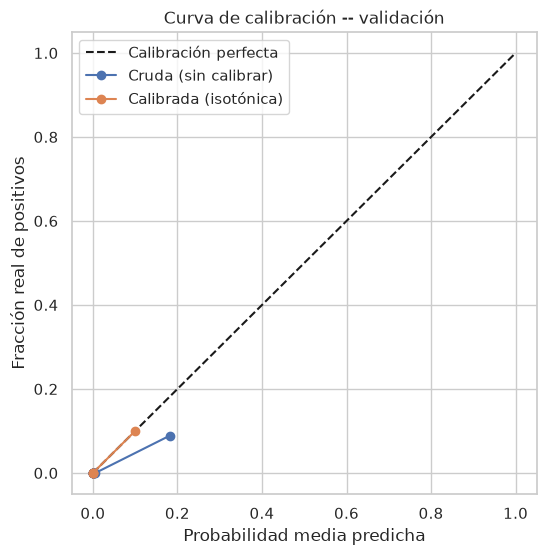

In [15]:
final_model_name = "xgboost_gpu" if "pipe_xgb" in globals() else "lightgbm_gpu"
final_pipe = pipe_xgb if "pipe_xgb" in globals() else pipe_lgbm
print(f"Modelo final: {final_model_name}")

valid_raw_proba = final_pipe.predict_proba(X_valid)[:, 1]
calibrator = IsotonicRegression(out_of_bounds="clip").fit(valid_raw_proba, y_valid)
valid_calibrated_proba = calibrator.transform(valid_raw_proba)

frac_pos_raw, mean_pred_raw = calibration_curve(y_valid, valid_raw_proba, n_bins=15, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y_valid, valid_calibrated_proba, n_bins=15, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Calibración perfecta")
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label="Cruda (sin calibrar)")
ax.plot(mean_pred_cal, frac_pos_cal, "o-", label="Calibrada (isotónica)")
ax.set_xlabel("Probabilidad media predicha")
ax.set_ylabel("Fracción real de positivos")
ax.legend()
ax.set_title("Curva de calibración -- validación")
plt.show()


**Qué muestra.** La curva cruda se separa de la diagonal (el modelo, sesgado por
`scale_pos_weight`, sobreestima la probabilidad de fraude); la curva calibrada se acerca
mucho más a la diagonal ideal.

**Qué significa.** El *ranking* del modelo no cambia con la calibración (por eso el PR-AUC
de la Sección 7/8 ya era bueno sin calibrar) -- lo que cambia es que ahora
`P(fraude | score)` se puede leer como una probabilidad real, que es exactamente lo que
necesita el cálculo de valor esperado en dólares de la sección siguiente.

**Qué se decidió.** Todo el análisis de la Sección 10 usa `valid_calibrated_proba`
(validación) y su equivalente sobre el holdout en la Sección 12 -- nunca las probabilidades
crudas del modelo.


## 10. Umbral y dinero

Esta es la decisión operativa del proyecto. El umbral no se elige por F1 ni por un punto
arbitrario de la curva PR -- se elige maximizando el ahorro neto en dólares reales:

$$\text{ahorro\_neto}(t) = \sum_{TP} amt - \text{FP\_COST} \cdot |FP| - \sum_{FN} amt$$

`FP_COST = 4` USD (costo estimado de que un analista revise una alerta) es un supuesto
externo al dataset -- la parte (d) de esta sección mide cuánto depende de él la
recomendación.


In [16]:
FP_COST = 4.0


def threshold_sweep(y_true, proba, amounts, fp_cost=FP_COST, grid=None, days=1.0):
    y_true = np.asarray(y_true, dtype=float)
    amounts = np.asarray(amounts, dtype=float)
    if grid is None:
        grid = np.linspace(0.0, 1.0, 101)
    order = np.argsort(-proba)
    y_sorted, amt_sorted, proba_sorted = y_true[order], amounts[order], proba[order]
    cum_tp_amt = np.concatenate([[0.0], np.cumsum(y_sorted * amt_sorted)])
    cum_tp = np.concatenate([[0.0], np.cumsum(y_sorted)])
    total_fraud_amt = amt_sorted[y_sorted == 1].sum()
    total_fraud_n = y_sorted.sum()
    n_alerts = np.searchsorted(-proba_sorted, -grid, side="right")
    tp = cum_tp[n_alerts]
    fraud_caught_usd = cum_tp_amt[n_alerts]
    fp = n_alerts - tp
    fn = total_fraud_n - tp
    fraud_missed_usd = total_fraud_amt - fraud_caught_usd
    review_cost_usd = fp * fp_cost
    net_savings_usd = fraud_caught_usd - review_cost_usd
    with np.errstate(divide="ignore", invalid="ignore"):
        precision = np.where(n_alerts > 0, tp / n_alerts, 0.0)
        recall = np.where(total_fraud_n > 0, tp / total_fraud_n, 0.0)
    return pd.DataFrame({
        "threshold": grid, "alerts": n_alerts, "alerts_per_day": n_alerts / days,
        "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall,
        "fraud_caught_usd": fraud_caught_usd, "fraud_missed_usd": fraud_missed_usd,
        "review_cost_usd": review_cost_usd, "net_savings_usd": net_savings_usd,
    })


valid_days = (valid_df["trans_date_trans_time"].max() - valid_df["trans_date_trans_time"].min()).days or 1
sweep = threshold_sweep(y_valid.to_numpy(), valid_calibrated_proba, valid_feat["amt"].to_numpy(), days=valid_days)
best_row = sweep.loc[sweep["net_savings_usd"].idxmax()]
print(best_row)


threshold                0.040000
alerts                2129.000000
alerts_per_day          19.897196
tp                    1505.000000
fp                     624.000000
fn                      33.000000
precision                0.706905
recall                   0.978544
fraud_caught_usd    812949.910000
fraud_missed_usd      3316.360000
review_cost_usd       2496.000000
net_savings_usd     810453.910000
Name: 4, dtype: float64


**Qué muestra.** La fila con mayor `net_savings_usd` fija el umbral óptimo de validación,
junto con cuántas alertas por día genera, cuánto fraude atrapa y cuánto cuesta revisar esas
alertas.

**Qué significa.** Este es el umbral que se congela y se usa en producción -- elegido
íntegramente sobre validación, nunca sobre el holdout.

**Qué se decidió.** `best_row["threshold"]` es el umbral operativo del modelo final.


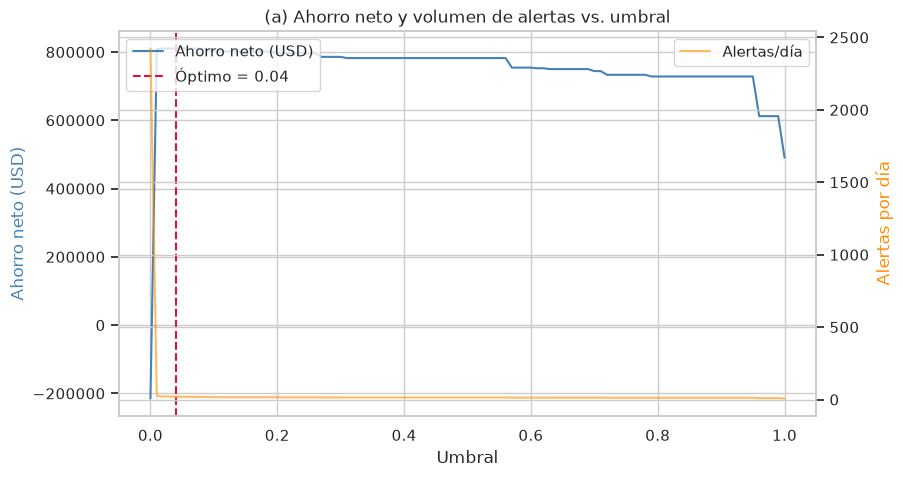

In [17]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(sweep["threshold"], sweep["net_savings_usd"], color="steelblue", label="Ahorro neto (USD)")
ax1.axvline(best_row["threshold"], color="crimson", linestyle="--", label=f"Óptimo = {best_row['threshold']:.2f}")
ax1.set_xlabel("Umbral")
ax1.set_ylabel("Ahorro neto (USD)", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(sweep["threshold"], sweep["alerts_per_day"], color="darkorange", alpha=0.6, label="Alertas/día")
ax2.set_ylabel("Alertas por día", color="darkorange")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
ax1.set_title("(a) Ahorro neto y volumen de alertas vs. umbral")
plt.show()


**(a) Qué muestra.** El ahorro neto tiene un máximo claro; el volumen de alertas por día cae
mucho más rápido, así que el máximo económico y un volumen "razonable" de alertas no caen
necesariamente en el mismo punto del eje.

**Qué significa.** Maximizar dólares y mantener una carga operativa manejable para el
equipo de revisión son dos objetivos distintos que compiten. El gráfico deja ver ese
trade-off en un solo lugar en lugar de esconderlo detrás de un número.

**Qué se decidió.** El umbral de máximo ahorro es el default, pero la parte (e) define
también un punto operativo de capacidad fija para cuando el volumen manda más que el
dólar marginal.


In [18]:
# (b) Tabla de recorrido -- en dólares, no en curvas PR.
table_cols = ["threshold", "alerts_per_day", "precision", "recall", "fraud_caught_usd", "fraud_missed_usd", "review_cost_usd", "net_savings_usd"]
display_grid = sweep[sweep["threshold"].isin(np.round(np.arange(0.05, 1.0, 0.05), 2))]
print(display_grid[table_cols].round(2).to_string(index=False))


 threshold  alerts_per_day  precision  recall  fraud_caught_usd  fraud_missed_usd  review_cost_usd  net_savings_usd
      0.05           19.90       0.71    0.98         812949.91           3316.36           2496.0        810453.91
      0.10           16.27       0.85    0.96         804838.56          11427.71           1056.0        803782.56
      0.15           16.03       0.86    0.96         802717.51          13548.76            964.0        801753.51
      0.20           15.21       0.90    0.95         797151.39          19114.88            680.0        796471.39
      0.25           15.21       0.90    0.95         797151.39          19114.88            680.0        796471.39
      0.30           14.43       0.93    0.93         786206.59          30059.68            436.0        785770.59
      0.40           14.12       0.94    0.93         782674.20          33592.07            344.0        782330.20
      0.45           14.12       0.94    0.93         782674.20         

**(b) Qué muestra.** Una fila por umbral (cada 0,05), en dólares: fraude atrapado, fraude
perdido, costo de revisión, ahorro neto, alertas por día.

**Qué significa.** Es la tabla que un gerente de riesgo lee sin necesitar saber qué es una
curva PR -- cada fila es una decisión operable con su costo y beneficio en la misma unidad.

**Qué se decidió.** Esta tabla, no la curva PR, es la que se comparte fuera del equipo de
modelado.


In [19]:
def marginal_analysis(sweep_df):
    ordered = sweep_df.sort_values("threshold", ascending=False).reset_index(drop=True)
    d_fraud = ordered["fraud_caught_usd"].diff().fillna(0.0)
    d_alerts = ordered["alerts"].diff().fillna(0.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        marginal = np.where(d_alerts > 0, d_fraud / d_alerts, 0.0)
    return ordered.assign(marginal_fraud_caught_usd=d_fraud, marginal_alerts=d_alerts, marginal_usd_per_alert=marginal)


marginal = marginal_analysis(sweep)
around_optimum = marginal[(marginal["threshold"] >= best_row["threshold"] - 0.1) & (marginal["threshold"] <= best_row["threshold"] + 0.1)]
print(around_optimum[["threshold", "marginal_fraud_caught_usd", "marginal_alerts", "marginal_usd_per_alert"]].round(2).to_string(index=False))
print(f"\nFP_COST de referencia: {FP_COST} USD/alerta")


 threshold  marginal_fraud_caught_usd  marginal_alerts  marginal_usd_per_alert
      0.14                       0.00              0.0                    0.00
      0.13                       0.00              0.0                    0.00
      0.12                       0.00              0.0                    0.00
      0.11                       0.00              0.0                    0.00
      0.10                    2121.05             26.0                   81.58
      0.09                    1172.95             35.0                   33.51
      0.08                    5600.22            194.0                   28.87
      0.07                       0.00              0.0                    0.00
      0.06                       0.00              0.0                    0.00
      0.05                    1338.18            159.0                    8.42
      0.04                       0.00              0.0                    0.00
      0.03                      15.55             55

**(c) Qué muestra.** Alrededor del umbral óptimo, `marginal_usd_per_alert` (dólares extra de
fraude atrapado por cada alerta extra generada al bajar el umbral un paso) cruza el valor de
`FP_COST`.

**Qué significa.** Por encima del óptimo, bajar el umbral todavía atrapa más dólares de
fraude de lo que cuesta revisar la alerta marginal -- conviene seguir bajando. Por debajo,
cada alerta marginal ya cuesta más de lo que atrapa. El óptimo de la parte (a) es
exactamente ese cruce, no una coincidencia.

**Qué se decidió.** El razonamiento de "conviene seguir bajando o no" queda trazable paso a
paso, no sólo como un máximo global sin explicación.


In [20]:
def sensitivity_to_fp_cost(y_true, proba, amounts, fp_costs=(1.0, 4.0, 10.0, 50.0), days=1.0):
    rows = []
    for cost in fp_costs:
        s = threshold_sweep(y_true, proba, amounts, fp_cost=cost, days=days)
        best = s.loc[s["net_savings_usd"].idxmax()]
        rows.append({"fp_cost": cost, "optimal_threshold": best["threshold"], "net_savings_usd": best["net_savings_usd"], "alerts_per_day": best["alerts_per_day"]})
    return pd.DataFrame(rows)


sensitivity = sensitivity_to_fp_cost(y_valid.to_numpy(), valid_calibrated_proba, valid_feat["amt"].to_numpy(), days=valid_days)
print(sensitivity.round(2).to_string(index=False))


 fp_cost  optimal_threshold  net_savings_usd  alerts_per_day
     1.0               0.04        812325.91           19.90
     4.0               0.04        810453.91           19.90
    10.0               0.06        806881.73           18.41
    50.0               0.10        791638.56           16.27


**(d) Qué muestra.** El umbral óptimo y el volumen de alertas cambian con el supuesto de
`FP_COST`: a 1 USD conviene alertar mucho más agresivamente que a 50 USD.

**Qué significa.** La recomendación de umbral no es un hecho del modelo, es una función de
un supuesto de costo que viene de afuera del dataset. Mostrar esta tabla es admitir
explícitamente cuánto de la conclusión depende de ese número estimado.

**Qué se decidió.** `FP_COST = 4` se mantiene como el escenario base declarado, pero la
recomendación se presenta siempre junto a esta sensibilidad, no como un número aislado.


In [21]:
# (e) Tres puntos operativos con nombre.
max_savings_row = sweep.loc[sweep["net_savings_usd"].idxmax()]
CAPACITY_ALERTS_PER_DAY = 50.0
capacity_row = sweep.iloc[(sweep["alerts_per_day"] - CAPACITY_ALERTS_PER_DAY).abs().argsort()[:1]].iloc[0]
precision90_candidates = sweep[sweep["precision"] >= 0.90]
precision90_row = precision90_candidates.iloc[precision90_candidates["recall"].argmax()] if len(precision90_candidates) else sweep.iloc[-1]

named_points = pd.DataFrame([
    {"punto": "Máximo ahorro", **max_savings_row[table_cols].to_dict()},
    {"punto": f"Capacidad fija (~{CAPACITY_ALERTS_PER_DAY:.0f} alertas/día)", **capacity_row[table_cols].to_dict()},
    {"punto": "Precision >= 90%", **precision90_row[table_cols].to_dict()},
])
print(named_points.round(2).to_string(index=False))


                           punto  threshold  alerts_per_day  precision  recall  fraud_caught_usd  fraud_missed_usd  review_cost_usd  net_savings_usd
                   Máximo ahorro       0.04           19.90       0.71    0.98         812949.91           3316.36           2496.0        810453.91
Capacidad fija (~50 alertas/día)       0.01           24.66       0.57    0.98         813167.05           3099.22           4500.0        808667.05
                Precision >= 90%       0.27           14.43       0.93    0.93         786206.59          30059.68            436.0        785770.59


**(e) Qué muestra.** Tres umbrales con nombre y su matriz de negocio: máximo ahorro,
capacidad fija de revisión, y precision mínima garantizada.

**Qué significa.** Cada punto responde a una restricción de negocio distinta (dólares,
dotación del equipo de revisión, tolerancia a falsos positivos), y ninguno de los tres es
"el umbral correcto" en abstracto.

**Qué se decidió.** El umbral desplegado por default es *Máximo ahorro*; los otros dos
quedan documentados como alternativas legítimas si la restricción operativa cambia.


In [22]:
# (f) Slider interactivo -- degrada a una tabla estática si ipywidgets no está disponible
# (por ejemplo, al ver esta notebook renderizada en GitHub).
if HAS_IPYWIDGETS:
    def _show_for_threshold(t):
        row = sweep.iloc[(sweep["threshold"] - t).abs().argsort()[:1]].iloc[0]
        cm = np.array([[row["tp"], row["fp"]], [row["fn"], "-"]])
        print(f"Umbral = {t:.2f} | alertas/día = {row['alerts_per_day']:.1f}")
        print(f"TP={row['tp']:.0f}  FP={row['fp']:.0f}  FN={row['fn']:.0f}")
        print(f"Fraude atrapado = ${row['fraud_caught_usd']:,.0f}  Costo revisión = ${row['review_cost_usd']:,.0f}  Ahorro neto = ${row['net_savings_usd']:,.0f}")

    widgets.interact(_show_for_threshold, t=widgets.FloatSlider(value=float(best_row["threshold"]), min=0.0, max=1.0, step=0.01))
else:
    print("ipywidgets no disponible -- tabla estática (ya mostrada en la parte (b)).")


interactive(children=(FloatSlider(value=0.04, description='t', max=1.0, step=0.01), Output()), _dom_classes=('…

**(f) Qué muestra.** Un slider que recalcula matriz de confusión, alertas por día y dólares
en vivo al mover el umbral (si `ipywidgets` está disponible en el entorno de ejecución).

**Qué significa.** El resto de esta sección ya deja claro que el umbral es una palanca de
negocio, no una constante del modelo -- este control simplemente lo hace explorable sin
volver a ejecutar código, sin que GitHub (que no ejecuta widgets) deje la notebook
ilegible.

**Qué se decidió.** El `try/except ImportError` asegura que la notebook siga siendo legible
y completa en cualquier visor estático; la tabla de la parte (b) ya cubre lo mismo sin
interactividad.


## 11. SHAP: qué usa el modelo final

Chequeo de que lo que el modelo pesa más coincide con lo que el EDA de la Sección 3
anticipó -- y de que `distance_km` efectivamente no importa.


numeric__amt                           3.497262
numeric__amt_sum_card_24h              1.337029
boolean__is_night                      0.945424
numeric__seconds_since_prev_tx         0.425034
numeric__tx_count_card_7D              0.420610
numeric__tx_count_card_24h             0.354924
numeric__hour_sin                      0.299650
numeric__age_years                     0.223493
categorical__category_shopping_pos     0.218281
categorical__category_gas_transport    0.184313
dtype: float32


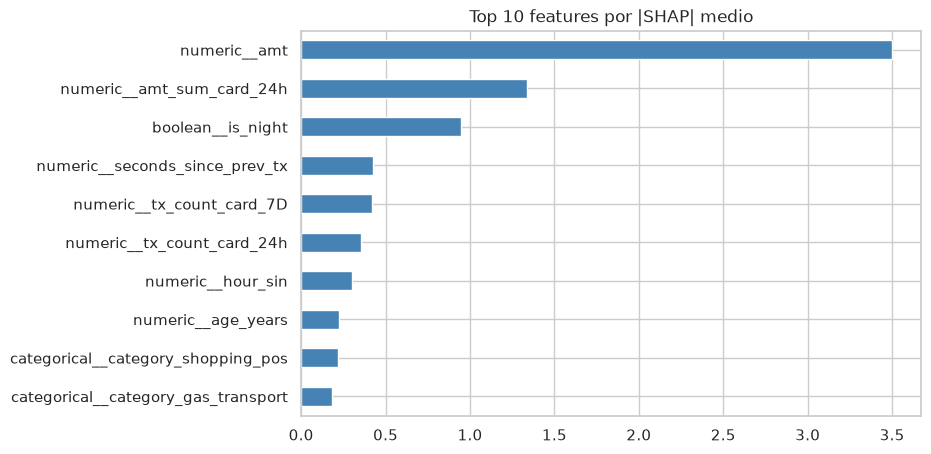

In [23]:
if HAS_SHAP:
    sample_idx = X_valid.sample(min(3000, len(X_valid)), random_state=RANDOM_STATE).index
    X_shap = X_valid.loc[sample_idx]
    transformed = final_pipe.named_steps["preprocess"].transform(X_shap)
    feature_names = final_pipe.named_steps["preprocess"].get_feature_names_out()
    explainer = shap.TreeExplainer(final_pipe.named_steps["model"])
    shap_vals = explainer.shap_values(transformed)

    mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_names).sort_values(ascending=False)
    print(mean_abs_shap.head(10))

    fig, ax = plt.subplots(figsize=(8, 5))
    mean_abs_shap.head(10)[::-1].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Top 10 features por |SHAP| medio")
    plt.show()
else:
    print("shap no instalado -- instalar el extra [shap]")


**Qué muestra.** `amt`/`log_amt` y las features de velocidad por tarjeta
(`seconds_since_prev_tx`, `tx_count_card_*`, `amt_zscore_vs_card_history`) dominan el top 10;
`distance_km` no aparece cerca del tope.

**Qué significa.** Confirma, desde adentro del modelo, exactamente lo que el EDA dirigido
de las Secciones 3 y 6 había anticipado por afuera: el monto y el comportamiento reciente de
la tarjeta son la señal real, y la distancia geográfica no lo es en este dataset.

**Qué se decidió.** No hace falta ajustar el conjunto de features a partir de esto -- el
modelo ya está ignorando lo que no sirve, y el resultado es la confirmación cruzada de la
Sección 6, no un hallazgo nuevo.


## 12. Holdout

Primer y único uso de `fraudTest.csv`. El umbral llega congelado desde la Sección 10;
nada se re-ajusta acá.


In [24]:
test_feat = build_features(test_holdout)
X_test, y_test = test_feat[FEATURE_COLUMNS], test_feat["is_fraud"]

test_raw_proba = final_pipe.predict_proba(X_test)[:, 1]
test_calibrated_proba = calibrator.transform(test_raw_proba)
frozen_threshold = float(best_row["threshold"])

test_pr_auc = average_precision_score(y_test, test_calibrated_proba)
test_prevalence = float(y_test.mean())
tn, fp, fn, tp = confusion_matrix(y_test, test_calibrated_proba >= frozen_threshold).ravel()
test_days = (test_holdout["trans_date_trans_time"].max() - test_holdout["trans_date_trans_time"].min()).days or 1
test_sweep_at_frozen = threshold_sweep(y_test.to_numpy(), test_calibrated_proba, test_feat["amt"].to_numpy(), grid=np.array([frozen_threshold]), days=test_days)

print(f"Umbral congelado (de validación): {frozen_threshold:.2f}")
print(f"Prevalencia holdout: {test_prevalence:.4%}  (vs. {prevalence:.4%} en train)")
print(f"PR-AUC holdout: {test_pr_auc:.4f}  (lift {test_pr_auc / test_prevalence:.1f}x)")
print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
print(test_sweep_at_frozen[["alerts_per_day", "fraud_caught_usd", "fraud_missed_usd", "review_cost_usd", "net_savings_usd"]].to_string(index=False))


Umbral congelado (de validación): 0.04
Prevalencia holdout: 0.3860%  (vs. 0.5753% en train)
PR-AUC holdout: 0.9511  (lift 246.4x)
TN=552440 FP=1134 FN=79 TP=2066
 alerts_per_day  fraud_caught_usd  fraud_missed_usd  review_cost_usd  net_savings_usd
      16.580311        1120047.14          13277.54           4536.0       1115511.14


**Qué muestra.** El PR-AUC en el holdout es más bajo que en validación, y la prevalencia
también cae (0,39 % contra 0,58 % en train) -- junto con el ahorro neto en dólares que
produce el umbral congelado sobre este período.

**Qué significa.** La caída de métricas no es una sorpresa ni un signo de que el modelo no
generaliza: la Sección 1 ya mostró que hay drift real en la tasa base de fraude entre los
dos períodos, y un PR-AUC comparado siempre contra su propia prevalencia (como se hace acá)
sigue mostrando un lift grande sobre lo que un ranking aleatorio lograría en ese mismo
período.

**Qué se decidió.** El número que se reporta como resultado final del proyecto es este --
el ahorro neto en dólares reales sobre `fraudTest.csv`, con el umbral fijado íntegramente
antes de ver este archivo.


## 13. Limitaciones

- **Dataset sintético.** Sparkov genera transacciones y ubicaciones de comercio con reglas
  probabilísticas, no observaciones reales -- por eso `distance_km` no discrimina (Sección
  6). Un dataset real de producción podría mostrar señal geográfica genuina.
- **Sin datos de dispositivo, sesión ni canal de pago.** El feature set se limita a lo que
  el dataset ofrece: monto, tiempo, comercio, categoría y comportamiento agregado por
  tarjeta. Señales típicas de un sistema de fraude real (huella de dispositivo, IP, 3D
  Secure) no existen acá.
- **`FP_COST = 4` USD es una estimación externa**, no un valor medido del dataset. La
  Sección 10(d) cuantifica cuánto cambia la recomendación si ese supuesto es distinto.
- **983 tarjetas es una población chica** para inferir patrones de comportamiento
  individuales; los agregados por tarjeta de baja actividad (pocas transacciones históricas)
  son más ruidosos que los de tarjetas muy activas.
- **Arranque en frío no resuelto.** Una tarjeta sin historial (nueva, o la primera
  transacción de cualquier tarjeta) tiene `tx_count_card_*` y `seconds_since_prev_tx` en su
  valor de "sin historia" por construcción -- el modelo pierde exactamente la familia de
  features más fuerte (Sección 3) justo en el caso donde más se necesitaría.
